In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [3]:
using Revise
includet("./base.jl")

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  31242.0 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 37 seconds. 540 already precompiled. 4 skipped due to circular dependency.


In [16]:
using CairoMakie
using GLMakie
CairoMakie.activate!()


In [8]:
f = jldopen("./data1.jld2")
dxs = f["dxs"]
sols = f["sols"]
fmetadata = f["metadata"]

L = fmetadata.L;

In [38]:
string(fmetadata)

"(K = 10.0, l = 0.99, p = 1.0, DN = 1.0e-6, T = 1.0e8, L = 10, u0_base = [100.0, 0.0, 0.0], tol = 2.220446049250313e-12, maxtime = 3600, run_threads = 4, solver_threads = 32)"

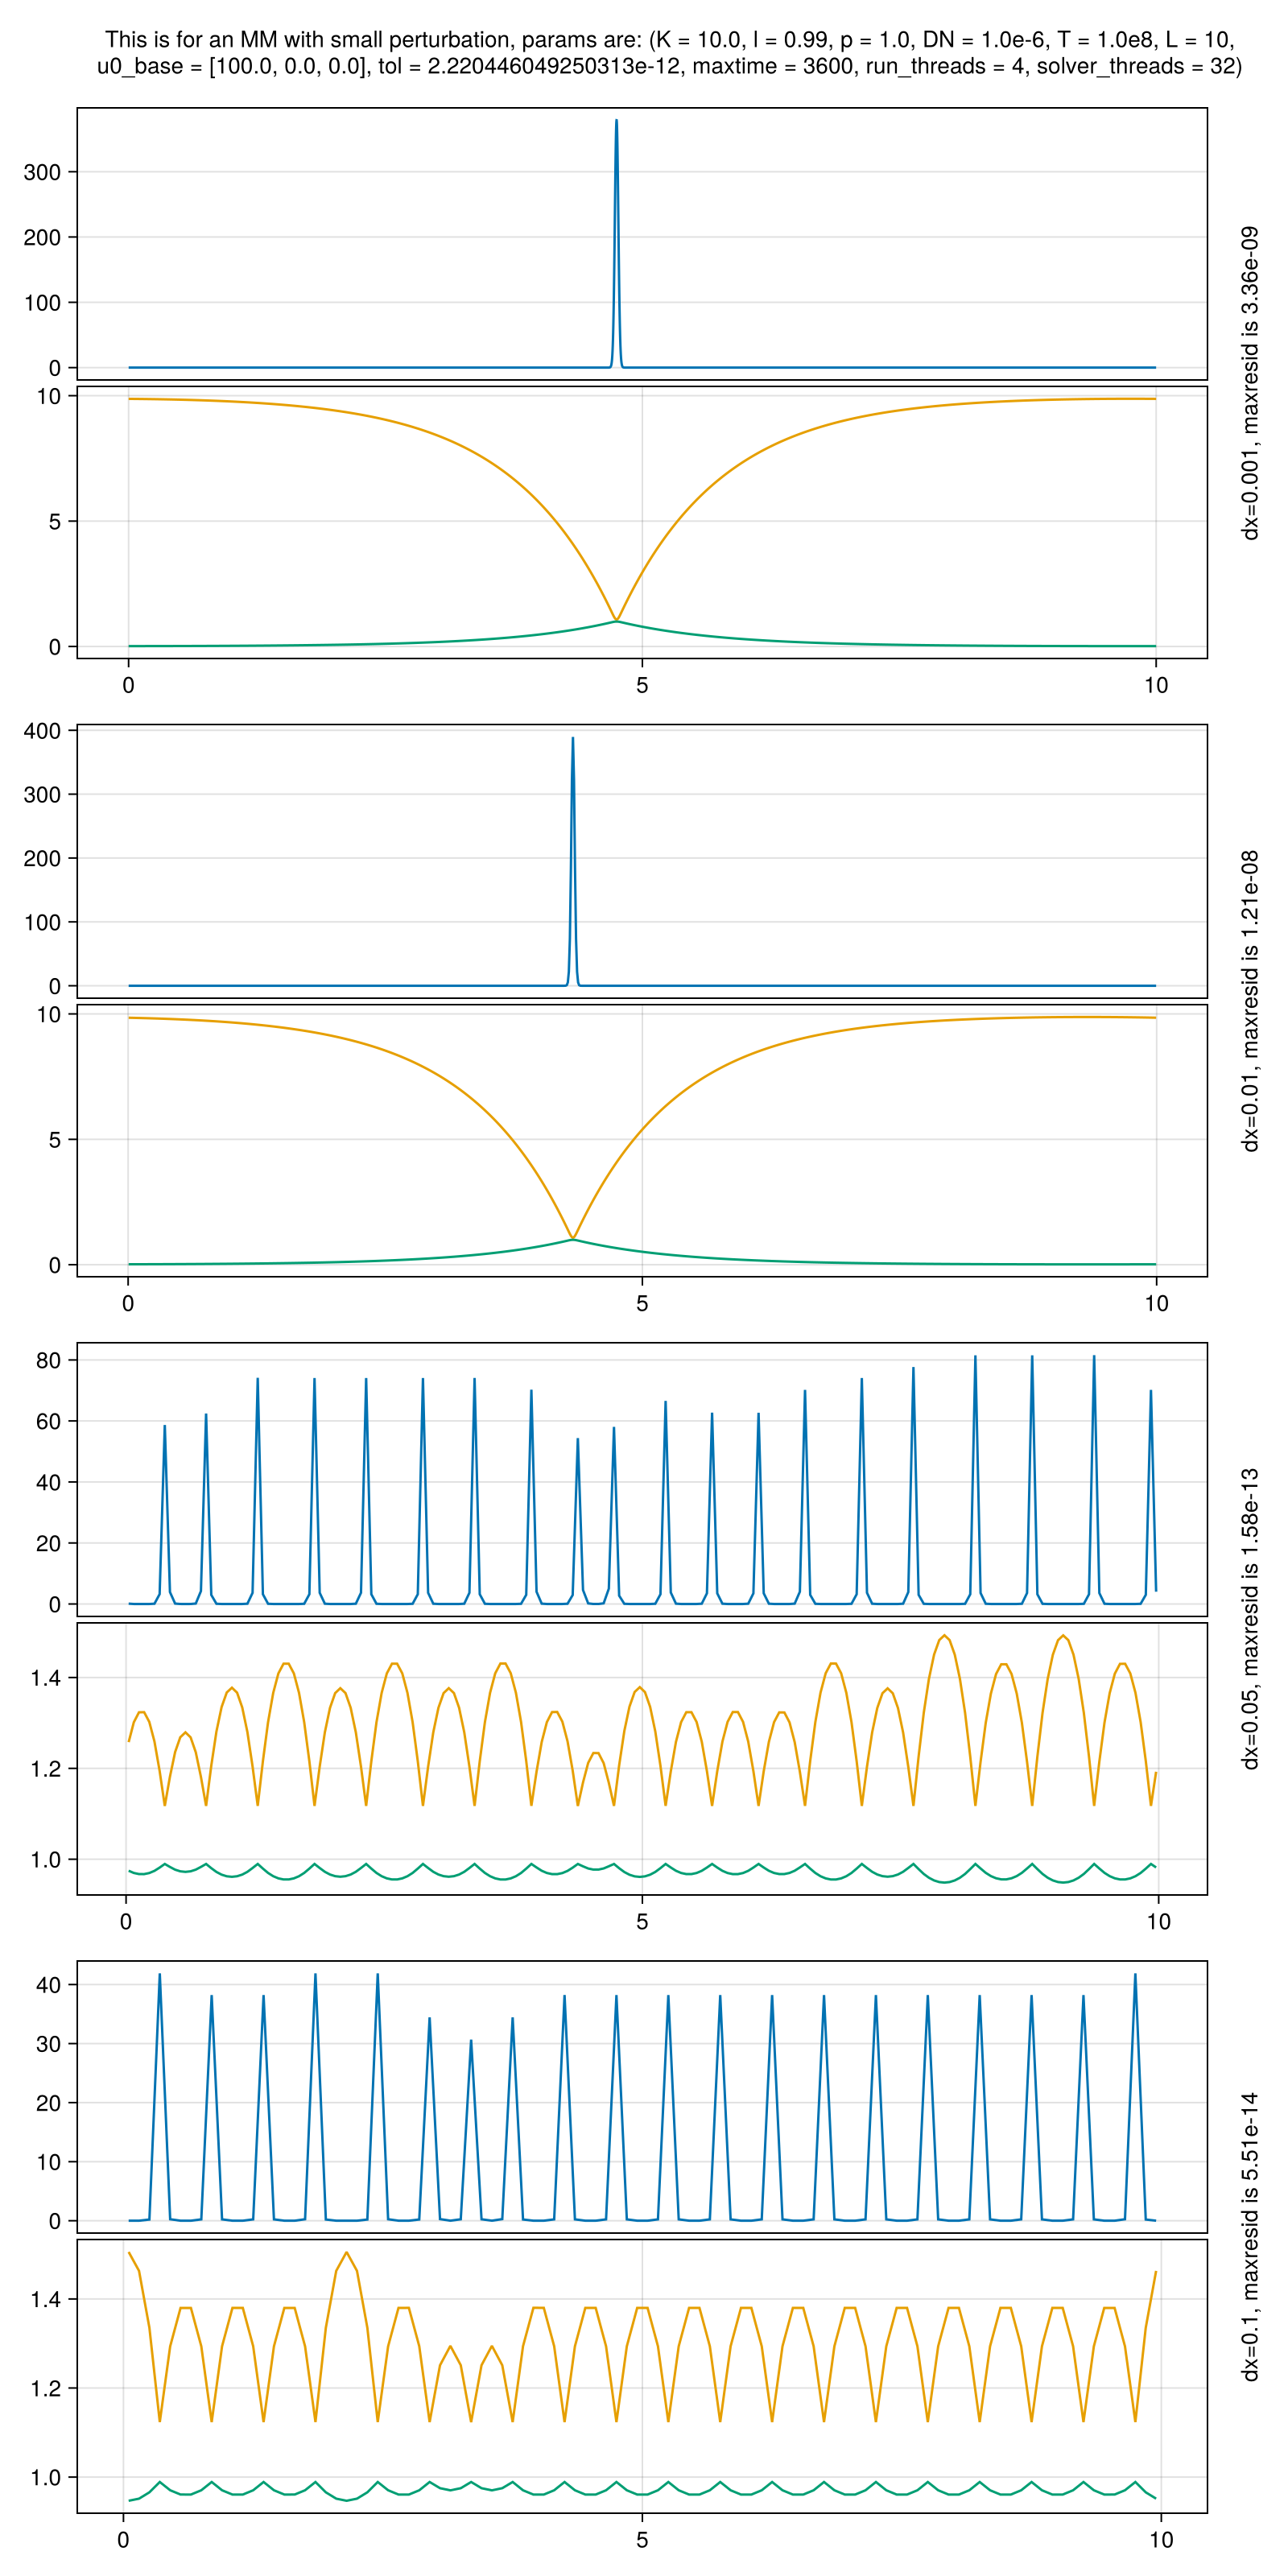

In [45]:
fig = Figure(;
    size=(800, 400 * length(dxs))
)

for ii in 1:length(dxs)
    sol = sols[ii]
    dx = dxs[ii]
    fs = sol.u[end]
    sN = size(fs, 2)

    plot_spatial_fs!(fig[ii,1], fs, 1, sN, dx)
    Label(fig[ii, 2], (@sprintf "dx=%.3g, maxresid is %.3g" dx smmicrmmaxresid(sol));
        tellheight=false,
        rotation=pi/2,
    )
end

Label(fig[0,:], "This is for an MM with small perturbation, params are: " * string(fmetadata);
    tellwidth=false,
    word_wrap=true,
)

Makie.save("./results.pdf", fig)

fig

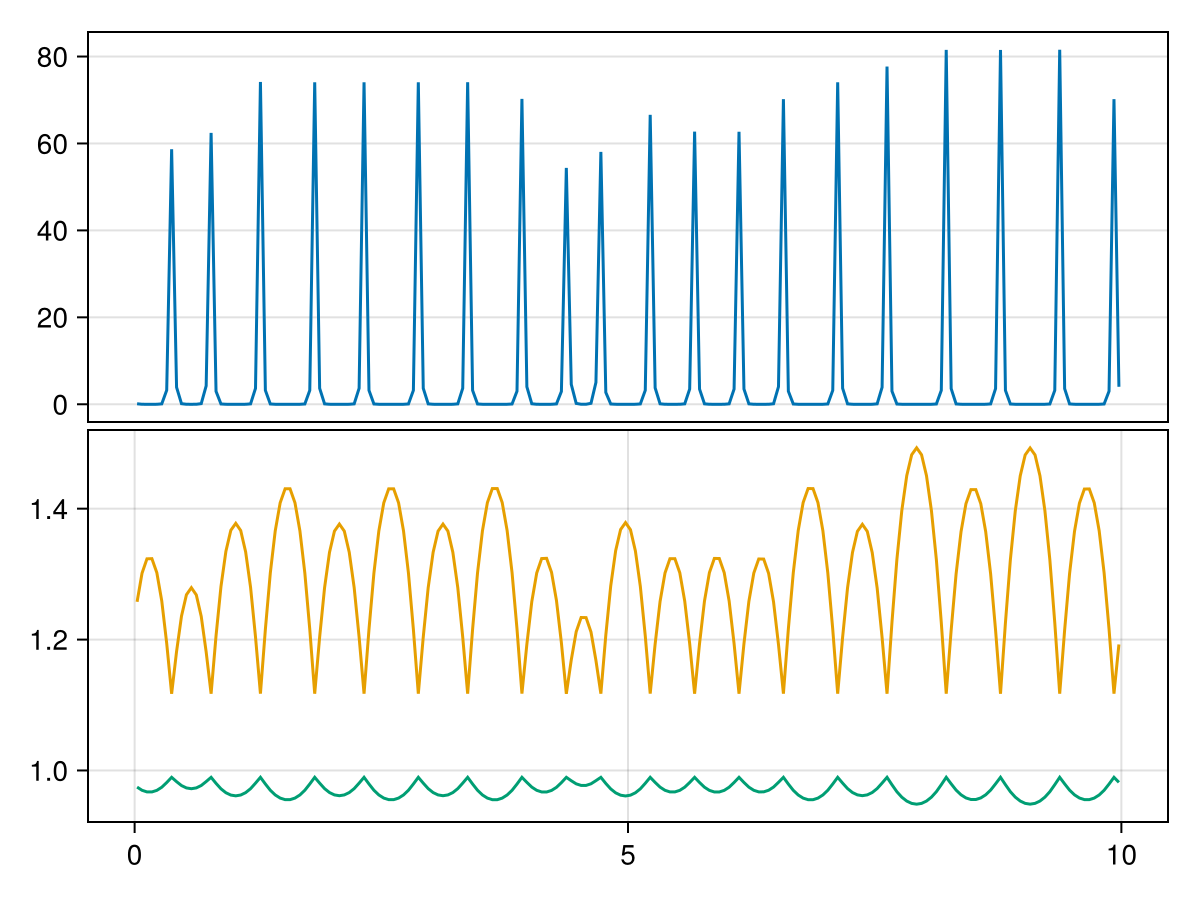

In [28]:
ii = 3
sol = sols[ii]
dx = dxs[ii]
fs = sol.u[end]
sN = size(fs, 2)

plot_spatial_fs(fs, 1, sN, dx)

In [31]:
f = plot_1dsmmicrm_sol_interactive(sol)
display(GLMakie.Screen(), f)
# f

GLMakie.Screen(...)

In [32]:
smmicrmmaxresid(sol)

1.580957587066223e-13